# Task 3: Contrastive Learning and CLIP
EE-5102/CS-6304 - Advanced Topics in Machine Learning - Programming Assignment 0

This notebook implements all subtasks of the CLIP section:
1. Zero-shot classification on STL-10 (plain / prompted / descriptive prompts)
2. Exploring the modality gap between CLIP's image and text embeddings
3. Bridging the modality gap with an orthogonal Procrustes alignment


## 0. Setup

In [1]:
!pip -q install git+https://github.com/openai/CLIP.git ftfy regex umap-learn --upgrade

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.5/40.5 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 801.8/801.8 kB 37.5 MB/s eta 0:00:00


In [2]:
import torch
import torch.nn.functional as F
import clip
import torchvision
from torchvision.datasets import STL10
from torch.utils.data import DataLoader, Subset
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import random, os, time
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DATA_DIR = "../data/Part3_Datasets"
WEIGHTS_DIR = "../weights"
os.makedirs(WEIGHTS_DIR, exist_ok=True)

# GPU info
print("Using device:", device)
if torch.cuda.is_available():
    print(f"Num GPUs: {torch.cuda.device_count()}")

    current_device = torch.cuda.current_device()
    print(f"Current Device Index: {current_device}")
    print(f"Device Name: {torch.cuda.get_device_name(current_device)}")

    props = torch.cuda.get_device_properties(current_device)
    print(f"Total Memory: {props.total_memory / 1e9:.2f} GB")
    print(f"CUDA Capability: {props.major}.{props.minor}")
else:
    print("PyTorch is currently using the CPU.")

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)


Using device: cuda
Num GPUs: 1
Current Device Index: 0
Device Name: Tesla T4
Total Memory: 15.64 GB
CUDA Capability: 7.5


### Data: STL-10 + CLIP model
We load OpenAI's official CLIP implementation (`ViT-B/32`) and use its bundled `preprocess`
transform (resize/center-crop to 224x224, CLIP normalization) directly as the `torchvision`
transform for STL-10. STL-10's 10 classes overlap closely with common ImageNet-style
categories, which makes it a good testbed for CLIP's zero-shot classification.

In [3]:
CLIP_WEIGHTS_DIR = os.path.abspath(os.path.join(WEIGHTS_DIR, "clip_vit_b_32"))
os.makedirs(CLIP_WEIGHTS_DIR, exist_ok=True)

model, preprocess = clip.load("ViT-B/32", device=device, download_root=CLIP_WEIGHTS_DIR)
model.eval()

test_set = STL10(root=DATA_DIR, split="test", download=True, transform=preprocess)
test_loader = DataLoader(test_set, batch_size=128, shuffle=False, num_workers=2)

stl_classes = test_set.classes
print(f"STL-10 test set size: {len(test_set)}")
print("Classes:", stl_classes)


100%|███████████████████████████████████████| 338M/338M [00:04<00:00, 77.3MiB/s]
100%|██████████| 2.64G/2.64G [09:23<00:00, 4.68MB/s]


STL-10 test set size: 8000
Classes: ['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck']


In [4]:
# import kagglehub


# # Use output_dir to specify the target folder on your machine
# dataset_path = kagglehub.dataset_download("jessicali9530/stl10", output_dir=DATA_DIR)

# print(f"Downloaded files to: {dataset_path}")

## 1. Zero-Shot Classification on STL-10

We build a "zero-shot classifier" by embedding a text prompt for every class with CLIP's text
encoder, then classifying each image by the class whose text embedding has the highest cosine
similarity to the image embedding. We compare three prompting strategies: plain class names,
the standard `"a photo of a {class}"` template used in the CLIP paper, and a more descriptive
variant.

In [5]:
prompt_templates = {
    "plain":       lambda c: f"{c}",
    "photo":       lambda c: f"a photo of a {c}",
    "descriptive": lambda c: f"a high quality photo of a {c}, a common object or animal",
}

@torch.no_grad()
def build_text_classifier(model, classnames, template_fn):
    """Embed one text prompt per class and L2-normalize -> (num_classes, dim)."""
    text_inputs = torch.cat([clip.tokenize(template_fn(c)) for c in classnames]).to(device)
    text_features = model.encode_text(text_inputs).float()
    text_features = text_features / text_features.norm(dim=-1, keepdim=True)
    return text_features


@torch.no_grad()
def evaluate_zero_shot(model, loader, text_features, desc="Zero-shot eval"):
    correct, total = 0, 0
    pbar = tqdm(loader, desc=desc, leave=False)
    for imgs, labels in pbar:
        imgs, labels = imgs.to(device), labels.to(device)
        image_features = model.encode_image(imgs).float()
        image_features = image_features / image_features.norm(dim=-1, keepdim=True)
        logits = 100.0 * image_features @ text_features.T
        preds = logits.argmax(dim=-1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        pbar.set_postfix(acc=f"{100.0 * correct / total:.2f}%")
    return 100.0 * correct / total  # accuracy as a percentage


In [6]:
text_features_by_prompt = {}
zero_shot_results = {}

for name, template_fn in prompt_templates.items():
    text_feats = build_text_classifier(model, stl_classes, template_fn)
    text_features_by_prompt[name] = text_feats
    acc = evaluate_zero_shot(model, test_loader, text_feats, desc=f"Zero-shot [{name}]")
    zero_shot_results[name] = acc
    print(f"[{name:11s}] zero-shot accuracy on STL-10 test set: {acc:.2f}%")


[plain      ] zero-shot accuracy on STL-10 test set: 96.26%


[photo      ] zero-shot accuracy on STL-10 test set: 97.38%


[descriptive] zero-shot accuracy on STL-10 test set: 96.42%


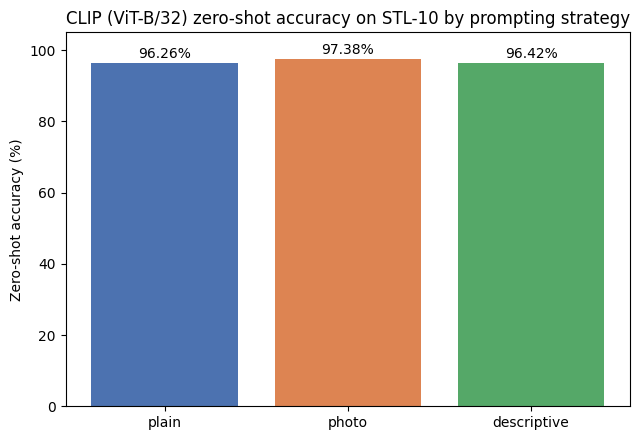

In [7]:
fig, ax = plt.subplots(figsize=(6.5, 4.5))
names = list(zero_shot_results.keys())
accs = list(zero_shot_results.values())
bars = ax.bar(names, accs, color=["#4C72B0", "#DD8452", "#55A868"])
ax.set_ylabel("Zero-shot accuracy (%)")
ax.set_title("CLIP (ViT-B/32) zero-shot accuracy on STL-10 by prompting strategy")
ax.set_ylim(0, 105)
for bar, v in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 1.5, f"{v:.2f}%", ha="center")
plt.tight_layout(); plt.show()


## 2. Exploring the Modality Gap

A well-known property of CLIP (and other dual-encoder contrastive models) is that image and
text embeddings, despite living in the same vector space and being trained to be close for
matching pairs, actually occupy two well-separated regions of that space: the so-called
*modality gap*. Since Part 1 compared three prompting strategies (plain class names, the
`"a photo of a {class}"` template, and a more descriptive variant), we look at the modality gap
for all three strategies here rather than just one. We visualize this directly by projecting a
mix of image embeddings and per-class text embeddings from all three prompting strategies into
2D with t-SNE, both coloured by embedding type (image vs. each text strategy) and, in a
duplicate plot, coloured by class with the embedding type shown by marker shape instead.


In [8]:
N_SAMPLES = 100

# This is the ONE fixed sample of images used for every plot/analysis in Sections 2 and 3
# below, so that the same images (and therefore the same per-class colour coding) show up
# consistently in the modality-gap t-SNE plots and in the before/after Procrustes plots.
subset_idx = np.random.choice(len(test_set), N_SAMPLES, replace=False)
subset = Subset(test_set, subset_idx)
subset_loader = DataLoader(subset, batch_size=32, shuffle=False)

@torch.no_grad()
def extract_image_embeddings(model, loader):
    feats, labs = [], []
    for imgs, labels in loader:
        imgs = imgs.to(device)
        f = model.encode_image(imgs).float()
        f = f / f.norm(dim=-1, keepdim=True)
        feats.append(f.cpu())
        labs.append(labels)
    return torch.cat(feats), torch.cat(labs)

image_embeds, image_labels = extract_image_embeddings(model, subset_loader)

prompt_names = list(prompt_templates.keys())  # ["plain", "photo", "descriptive"]

# Per-class text embeddings (10, dim), one dict entry per prompting strategy.
text_embeds_by_class_all = {name: text_features_by_prompt[name].cpu() for name in prompt_names}

# Text embeddings paired 1:1 with each sampled image (same class as that image), one dict
# entry per prompting strategy.
text_embeds_per_image_all = {
    name: text_embeds_by_class_all[name][image_labels] for name in prompt_names
}

print("Image embeddings:", image_embeds.shape)
for name in prompt_names:
    print(f"Per-class text embeddings [{name:11s}]:", text_embeds_by_class_all[name].shape)


Image embeddings: torch.Size([100, 512])
Per-class text embeddings [plain      ]: torch.Size([10, 512])
Per-class text embeddings [photo      ]: torch.Size([10, 512])
Per-class text embeddings [descriptive]: torch.Size([10, 512])


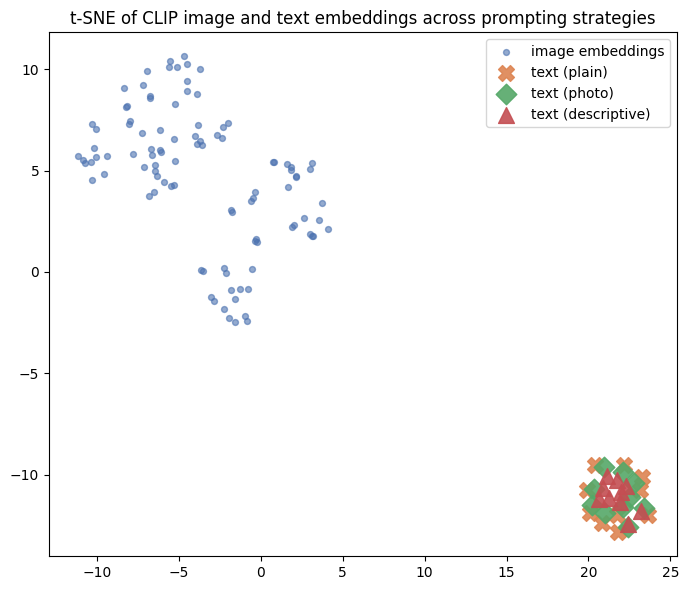

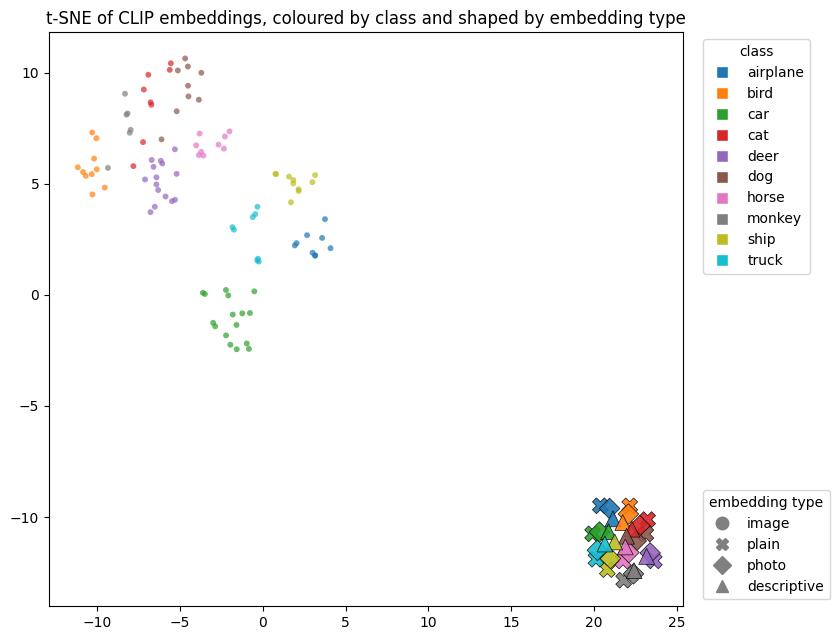

In [9]:
from sklearn.manifold import TSNE

# Combine image embeddings with per-class text embeddings from all three prompting
# strategies into a single array for one joint 2D projection.
combined = torch.cat(
    [image_embeds] + [text_embeds_by_class_all[name] for name in prompt_names], dim=0
).numpy()

embedding_type = np.array(
    ["image"] * len(image_embeds)
    + sum([[name] * len(text_embeds_by_class_all[name]) for name in prompt_names], [])
)

# Class index for every point: the image's own class for image embeddings, and the class
# index for each per-class text embedding. Used for the per-class colour-coded duplicate plot.
point_class = np.concatenate(
    [image_labels.numpy()] + [np.arange(len(stl_classes)) for _ in prompt_names]
)

emb2d = TSNE(n_components=2, init="pca", random_state=SEED, perplexity=30).fit_transform(combined)

# Style used to tell embedding types apart (colour AND shape).
type_style = {
    "image":       dict(color="#4C72B0", marker="o", size=18,  alpha=0.6, label="image embeddings"),
    "plain":       dict(color="#DD8452", marker="X", size=130, alpha=0.9, label="text (plain)"),
    "photo":       dict(color="#55A868", marker="D", size=110, alpha=0.9, label="text (photo)"),
    "descriptive": dict(color="#C44E52", marker="^", size=130, alpha=0.9, label="text (descriptive)"),
}

fig, ax = plt.subplots(figsize=(7, 6))
for etype, style in type_style.items():
    mask = embedding_type == etype
    ax.scatter(emb2d[mask, 0], emb2d[mask, 1], c=style["color"], marker=style["marker"],
               s=style["size"], alpha=style["alpha"], label=style["label"])
ax.set_title("t-SNE of CLIP image and text embeddings across prompting strategies")
ax.legend()
plt.tight_layout(); plt.show()

# --- Duplicate plot: colour coded by CLASS, with embedding type shown by marker shape ---
class_colors = plt.cm.tab10(np.linspace(0, 1, len(stl_classes)))
type_marker = {"image": "o", "plain": "X", "photo": "D", "descriptive": "^"}
type_size = {"image": 18, "plain": 130, "photo": 110, "descriptive": 130}
type_alpha = {"image": 0.7, "plain": 0.9, "photo": 0.9, "descriptive": 0.9}

fig, ax = plt.subplots(figsize=(8.5, 6.5))
for etype in ["image", "plain", "photo", "descriptive"]:
    mask = embedding_type == etype
    ax.scatter(
        emb2d[mask, 0], emb2d[mask, 1],
        c=[class_colors[c] for c in point_class[mask]],
        marker=type_marker[etype], s=type_size[etype], alpha=type_alpha[etype],
        edgecolors="black" if etype != "image" else "none", linewidths=0.5,
    )

class_handles = [plt.Line2D([0], [0], marker="s", color="w", markerfacecolor=class_colors[i],
                             markersize=8, label=stl_classes[i]) for i in range(len(stl_classes))]
type_handles = [plt.Line2D([0], [0], marker=type_marker[t], color="gray", linestyle="None",
                            markersize=9, label=t) for t in ["image", "plain", "photo", "descriptive"]]
legend1 = ax.legend(handles=class_handles, title="class", loc="upper left", bbox_to_anchor=(1.02, 1.0))
ax.add_artist(legend1)
ax.legend(handles=type_handles, title="embedding type", loc="lower left", bbox_to_anchor=(1.02, 0.0))
ax.set_title("t-SNE of CLIP embeddings, coloured by class and shaped by embedding type")
plt.tight_layout(); plt.show()


In [10]:
# Quantify the gap separately for each prompting strategy: distance between the image
# embedding centroid and that strategy's text embedding centroid, both before and after
# re-normalizing each centroid to unit length.
img_centroid = image_embeds.mean(dim=0)

gap_stats = {}
for name in prompt_names:
    txt_centroid = text_embeds_by_class_all[name].mean(dim=0)
    raw_gap = (img_centroid - txt_centroid).norm().item()
    norm_gap = (F.normalize(img_centroid, dim=0) - F.normalize(txt_centroid, dim=0)).norm().item()
    mean_img_text_cos = F.cosine_similarity(
        image_embeds, text_embeds_per_image_all[name], dim=-1
    ).mean().item()
    gap_stats[name] = dict(raw_gap=raw_gap, norm_gap=norm_gap, mean_img_text_cos=mean_img_text_cos)

mean_img_img_cos = F.cosine_similarity(
    image_embeds.unsqueeze(1), image_embeds.unsqueeze(0), dim=-1
).fill_diagonal_(float("nan"))
mean_img_img_cos = np.nanmean(mean_img_img_cos.numpy())

for name in prompt_names:
    s = gap_stats[name]
    print(f"[{name:11s}] centroid gap (raw): {s['raw_gap']:.4f}   "
          f"centroid gap (unit-normalized): {s['norm_gap']:.4f}   "
          f"mean cosine sim image<->matching text: {s['mean_img_text_cos']:.4f}")
print(f"Mean cosine sim, image<->image (within-modality): {mean_img_img_cos:.4f}")


[plain      ] centroid gap (raw): 1.0398   centroid gap (unit-normalized): 1.2124   mean cosine sim image<->matching text: 0.2518
[photo      ] centroid gap (raw): 1.0445   centroid gap (unit-normalized): 1.2072   mean cosine sim image<->matching text: 0.2640
[descriptive] centroid gap (raw): 1.0261   centroid gap (unit-normalized): 1.1789   mean cosine sim image<->matching text: 0.2857
Mean cosine sim, image<->image (within-modality): 0.6134


## 3. Bridging the Modality Gap

We align the two modalities with an **orthogonal Procrustes transform**: given paired image
features $X$ and text features $Y$, we solve

$$\min_{R \,:\, R^\top R = I} \lVert XR - Y \rVert_F$$

for an orthogonal rotation matrix $R$, using `scipy.linalg.orthogonal_procrustes` (which solves
this in closed form via an SVD of $X^\top Y$). Since Section 2 looked at all three prompting
strategies, we fit a separate rotation $R$ for each strategy here, using the same fixed set of
sampled images from Section 2 paired with that strategy's own per-class text embeddings, then
apply each $R$ to *all* CLIP image embeddings at inference time before comparing against that
strategy's (unrotated) class text embeddings.


In [11]:
from scipy.linalg import orthogonal_procrustes

X = image_embeds.numpy()  # (N_SAMPLES, dim) image features, same fixed sample as Section 2

procrustes_R = {}
X_aligned_all = {}
for name in prompt_names:
    Y = text_embeds_per_image_all[name].numpy()  # (N_SAMPLES, dim) paired text features
    R, _ = orthogonal_procrustes(X, Y)
    procrustes_R[name] = R
    X_aligned_all[name] = X @ R
    np.save(os.path.join(WEIGHTS_DIR, f"procrustes_R_{name}.npy"), R)
    print(f"[{name:11s}] learned rotation matrix R: {R.shape}")


[plain      ] learned rotation matrix R: (512, 512)
[photo      ] learned rotation matrix R: (512, 512)
[descriptive] learned rotation matrix R: (512, 512)


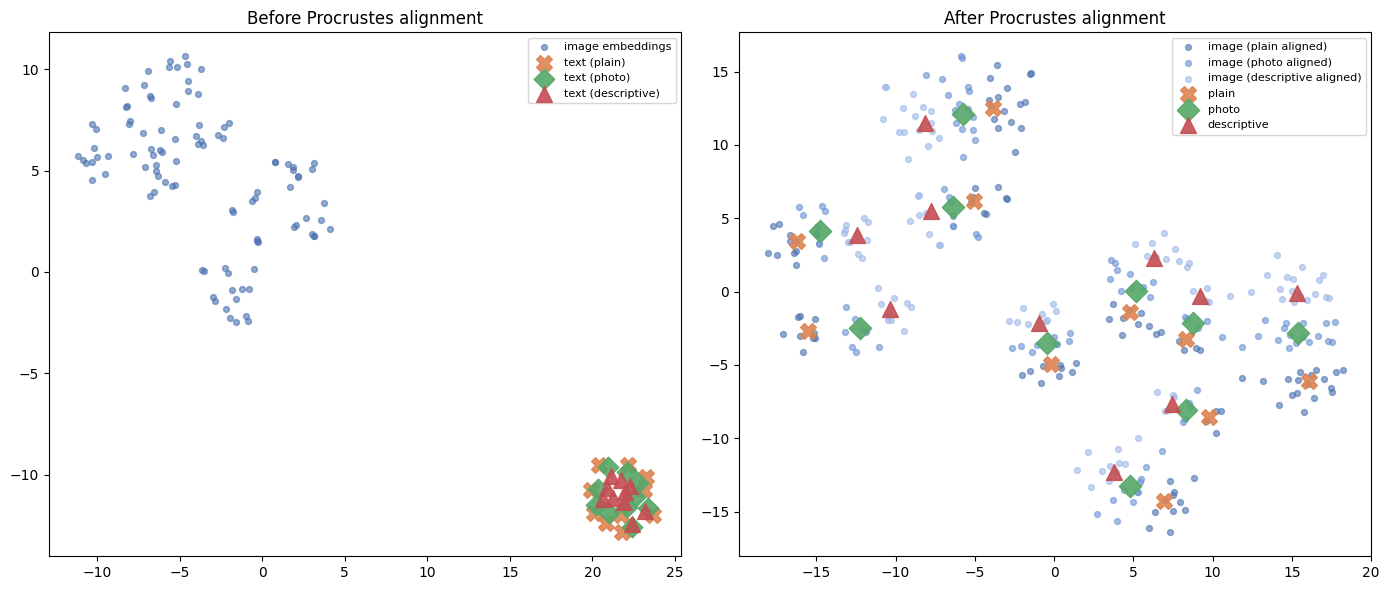

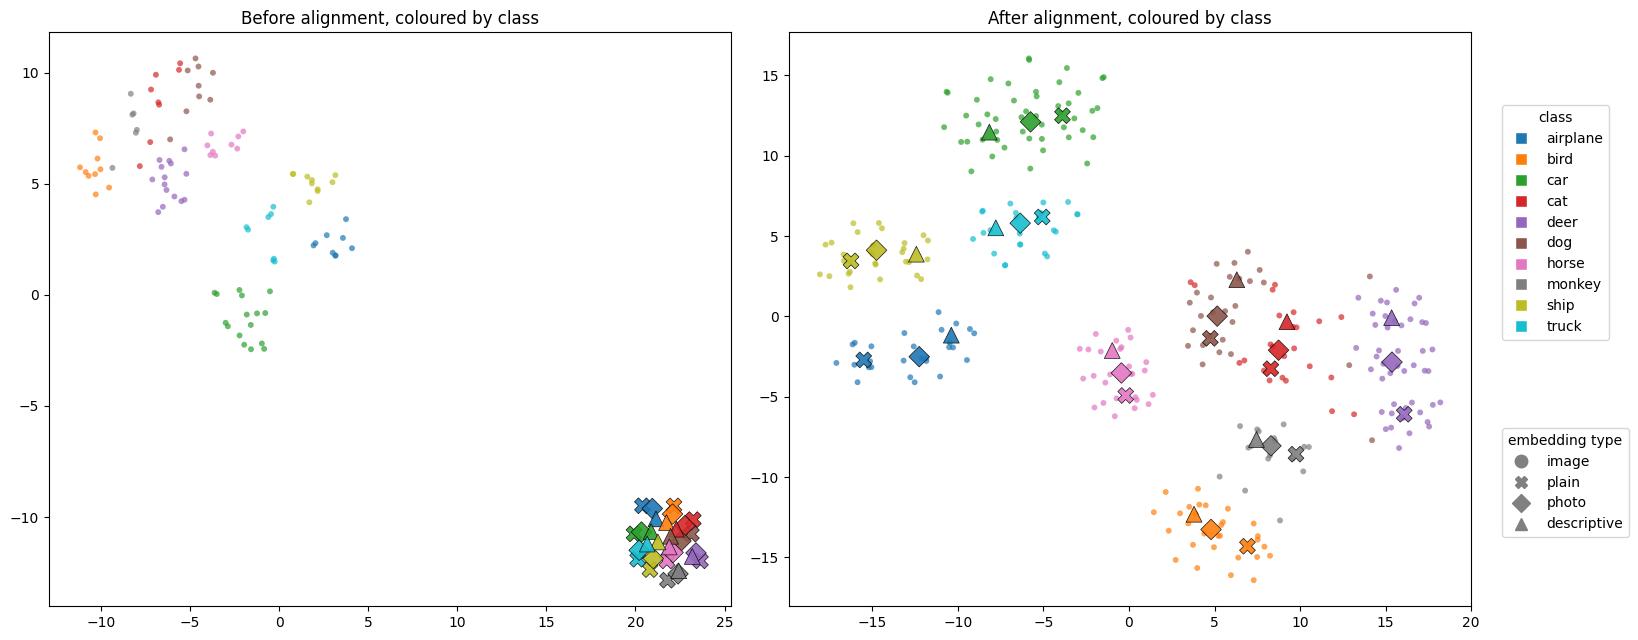

In [12]:
# Combine each strategy's Procrustes-aligned image embeddings with that strategy's per-class
# text embeddings. This uses the SAME fixed image sample as the "before" plot in Section 2,
# just rotated by that strategy's own R, so the two plots stay directly comparable.
combined_aligned = np.concatenate(
    [X_aligned_all[name] for name in prompt_names]
    + [text_embeds_by_class_all[name].numpy() for name in prompt_names],
    axis=0,
)
embedding_type_aligned = np.array(
    sum([[f"image ({name} aligned)"] * len(X) for name in prompt_names], [])
    + sum([[name] * len(stl_classes) for name in prompt_names], [])
)
point_class_aligned = np.concatenate(
    [image_labels.numpy() for _ in prompt_names] + [np.arange(len(stl_classes)) for _ in prompt_names]
)

emb2d_aligned = TSNE(n_components=2, init="pca", random_state=SEED, perplexity=30).fit_transform(combined_aligned)

# --- Main before/after plot, coloured by embedding type ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for etype, style in type_style.items():
    mask = embedding_type == etype
    axes[0].scatter(emb2d[mask, 0], emb2d[mask, 1], c=style["color"], marker=style["marker"],
                     s=style["size"], alpha=style["alpha"], label=style["label"])
axes[0].set_title("Before Procrustes alignment")
axes[0].legend(fontsize=8)

after_style = {
    "image (plain aligned)":       dict(color="#4C72B0", marker="o"),
    "image (photo aligned)":       dict(color="#6A93D4", marker="o"),
    "image (descriptive aligned)": dict(color="#9DB8E8", marker="o"),
    "plain":       dict(color="#DD8452", marker="X"),
    "photo":       dict(color="#55A868", marker="D"),
    "descriptive": dict(color="#C44E52", marker="^"),
}
for etype, style in after_style.items():
    mask = embedding_type_aligned == etype
    is_text = etype in prompt_names
    axes[1].scatter(emb2d_aligned[mask, 0], emb2d_aligned[mask, 1], c=style["color"],
                     marker=style["marker"], s=130 if is_text else 18,
                     alpha=0.9 if is_text else 0.6, label=etype)
axes[1].set_title("After Procrustes alignment")
axes[1].legend(fontsize=8)

plt.tight_layout(); plt.show()

# --- Duplicate before/after plot: coloured by CLASS, shaped by embedding type ---
type_marker_aligned = {
    "image (plain aligned)": "o", "image (photo aligned)": "o", "image (descriptive aligned)": "o",
    "plain": "X", "photo": "D", "descriptive": "^",
}
type_size_aligned = {
    "image (plain aligned)": 18, "image (photo aligned)": 18, "image (descriptive aligned)": 18,
    "plain": 130, "photo": 110, "descriptive": 130,
}
type_alpha_aligned = {
    "image (plain aligned)": 0.7, "image (photo aligned)": 0.7, "image (descriptive aligned)": 0.7,
    "plain": 0.9, "photo": 0.9, "descriptive": 0.9,
}

fig, axes = plt.subplots(1, 2, figsize=(15, 6.5))

for etype in ["image", "plain", "photo", "descriptive"]:
    mask = embedding_type == etype
    axes[0].scatter(
        emb2d[mask, 0], emb2d[mask, 1],
        c=[class_colors[c] for c in point_class[mask]],
        marker=type_marker[etype], s=type_size[etype], alpha=type_alpha[etype],
        edgecolors="black" if etype != "image" else "none", linewidths=0.5,
    )
axes[0].set_title("Before alignment, coloured by class")

for etype in type_marker_aligned:
    mask = embedding_type_aligned == etype
    is_text = etype in prompt_names
    axes[1].scatter(
        emb2d_aligned[mask, 0], emb2d_aligned[mask, 1],
        c=[class_colors[c] for c in point_class_aligned[mask]],
        marker=type_marker_aligned[etype], s=type_size_aligned[etype], alpha=type_alpha_aligned[etype],
        edgecolors="black" if is_text else "none", linewidths=0.5,
    )
axes[1].set_title("After alignment, coloured by class")

class_handles = [plt.Line2D([0], [0], marker="s", color="w", markerfacecolor=class_colors[i],
                             markersize=8, label=stl_classes[i]) for i in range(len(stl_classes))]
type_handles = [plt.Line2D([0], [0], marker=m, color="gray", linestyle="None", markersize=9, label=t)
                for t, m in [("image", "o"), ("plain", "X"), ("photo", "D"), ("descriptive", "^")]]
fig.legend(handles=class_handles, title="class", loc="center left", bbox_to_anchor=(1.0, 0.65))
fig.legend(handles=type_handles, title="embedding type", loc="center left", bbox_to_anchor=(1.0, 0.25))
plt.tight_layout(); plt.show()


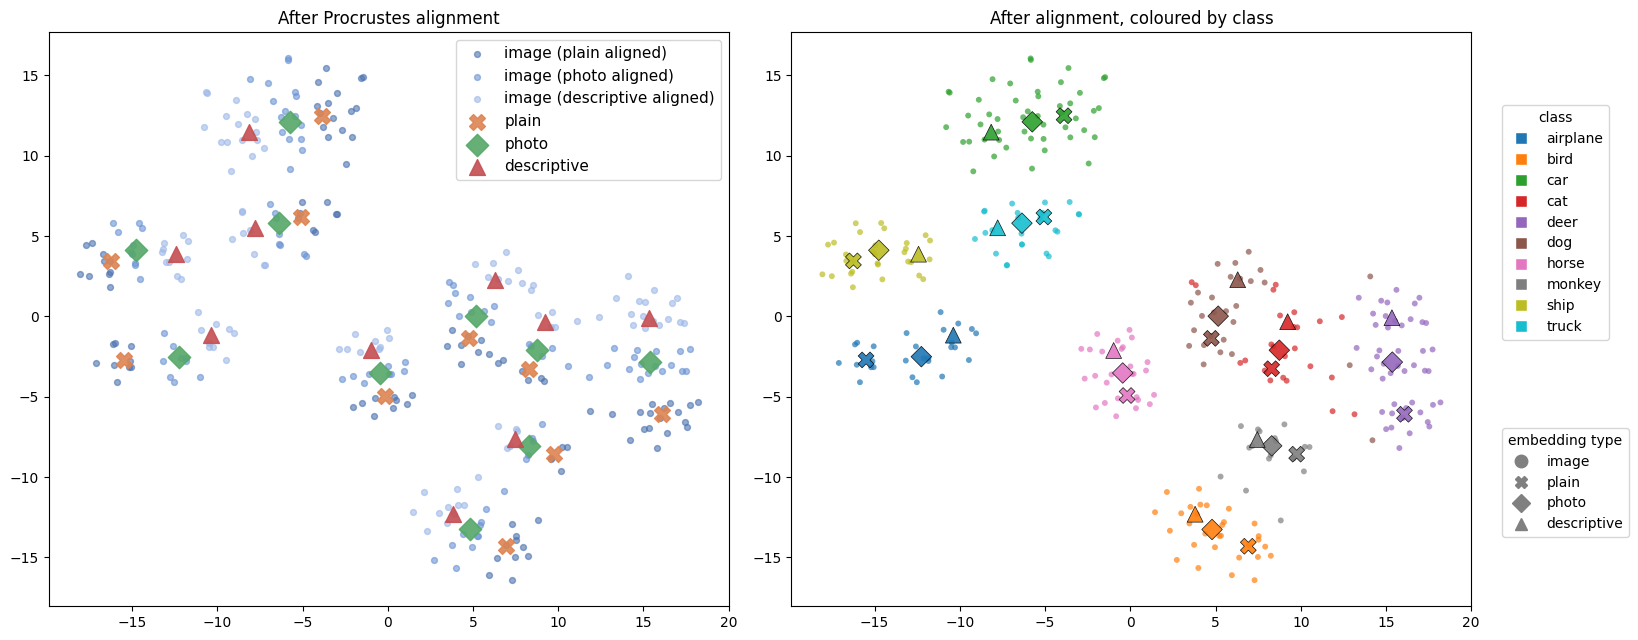

In [13]:
# --- Combined figure: "after alignment" panels only, coloured by embedding type (left)
# and coloured by class with embedding type shown via marker shape (right) ---
fig, axes = plt.subplots(1, 2, figsize=(15, 6.5))

# Left: after alignment, coloured by embedding type (same as axes[1] of the first figure)
for etype, style in after_style.items():
    mask = embedding_type_aligned == etype
    is_text = etype in prompt_names
    axes[0].scatter(emb2d_aligned[mask, 0], emb2d_aligned[mask, 1], c=style["color"],
                     marker=style["marker"], s=130 if is_text else 18,
                     alpha=0.9 if is_text else 0.6, label=etype)
axes[0].set_title("After Procrustes alignment")
axes[0].legend(fontsize=11, markerscale=1.0)

# Right: after alignment, coloured by class, shaped by embedding type (same as axes[1] of
# the duplicate figure)
for etype in type_marker_aligned:
    mask = embedding_type_aligned == etype
    is_text = etype in prompt_names
    axes[1].scatter(
        emb2d_aligned[mask, 0], emb2d_aligned[mask, 1],
        c=[class_colors[c] for c in point_class_aligned[mask]],
        marker=type_marker_aligned[etype], s=type_size_aligned[etype], alpha=type_alpha_aligned[etype],
        edgecolors="black" if is_text else "none", linewidths=0.5,
    )
axes[1].set_title("After alignment, coloured by class")

class_handles = [plt.Line2D([0], [0], marker="s", color="w", markerfacecolor=class_colors[i],
                             markersize=8, label=stl_classes[i]) for i in range(len(stl_classes))]
type_handles = [plt.Line2D([0], [0], marker=m, color="gray", linestyle="None", markersize=9, label=t)
                for t, m in [("image", "o"), ("plain", "X"), ("photo", "D"), ("descriptive", "^")]]
fig.legend(handles=class_handles, title="class", loc="center left", bbox_to_anchor=(1.0, 0.65))
fig.legend(handles=type_handles, title="embedding type", loc="center left", bbox_to_anchor=(1.0, 0.25))

plt.tight_layout(); plt.show()

In [14]:
@torch.no_grad()
def evaluate_zero_shot_aligned(model, loader, text_features, R, desc="Aligned zero-shot eval"):
    correct, total = 0, 0
    R_t = torch.tensor(R, dtype=torch.float32, device=device)
    pbar = tqdm(loader, desc=desc, leave=False)
    for imgs, labels in pbar:
        imgs, labels = imgs.to(device), labels.to(device)
        image_features = model.encode_image(imgs).float()
        image_features = image_features / image_features.norm(dim=-1, keepdim=True)
        image_features_aligned = image_features @ R_t
        logits = 100.0 * image_features_aligned @ text_features.T
        preds = logits.argmax(dim=-1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        pbar.set_postfix(acc=f"{100.0 * correct / total:.2f}%")
    return 100.0 * correct / total

acc_aligned = {}
for name in prompt_names:
    acc_aligned[name] = evaluate_zero_shot_aligned(
        model, test_loader, text_features_by_prompt[name].to(device), procrustes_R[name],
        desc=f"Aligned zero-shot [{name}]",
    )

for name in prompt_names:
    print(f"[{name:11s}] zero-shot accuracy BEFORE alignment: {zero_shot_results[name]:.2f}%   "
          f"AFTER alignment: {acc_aligned[name]:.2f}%")


[plain      ] zero-shot accuracy BEFORE alignment: 96.26%   AFTER alignment: 96.45%
[photo      ] zero-shot accuracy BEFORE alignment: 97.38%   AFTER alignment: 96.70%
[descriptive] zero-shot accuracy BEFORE alignment: 96.42%   AFTER alignment: 96.81%


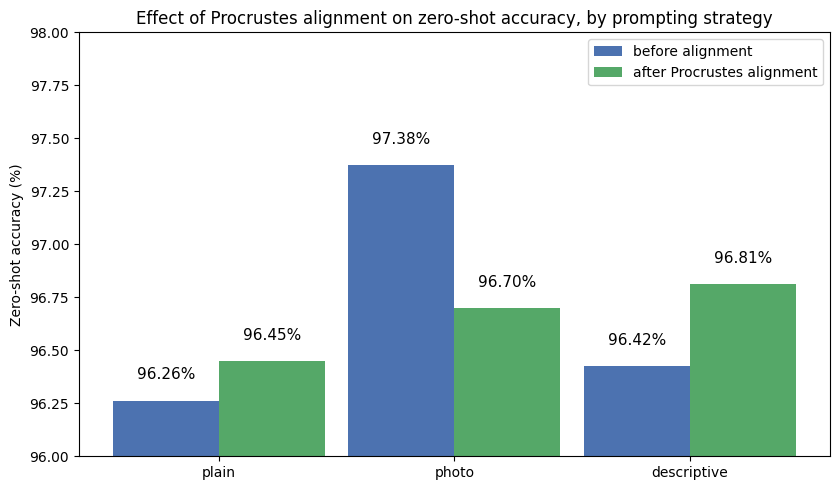

In [25]:
fig, ax = plt.subplots(figsize=(8.5, 5))
x = np.arange(len(prompt_names))
width = 0.45
before_vals = [zero_shot_results[name] for name in prompt_names]
after_vals = [acc_aligned[name] for name in prompt_names]

bars_before = ax.bar(x - width / 2, before_vals, width, label="before alignment", color="#4C72B0")
bars_after = ax.bar(x + width / 2, after_vals, width, label="after Procrustes alignment", color="#55A868")

ax.set_xticks(x)
ax.set_xticklabels(prompt_names)
ax.set_ylabel("Zero-shot accuracy (%)")
ax.set_title("Effect of Procrustes alignment on zero-shot accuracy, by prompting strategy")
ax.set_ylim(96, 98)
ax.legend()
for bars in (bars_before, bars_after):
    for bar in bars:
        v = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, v + 0.1, f"{v:.2f}%", ha="center", fontsize=11)
plt.tight_layout(); plt.show()

In [16]:
# # 1. Zip the weights/embeddings folder
# !zip -r weights_part3.zip /weights/

# # 2. Download the zip file to your local computer
# from google.colab import files
# files.download('weights_part3.zip')
from google.colab import runtime
runtime.unassign()
